In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import *
from keras.models import *
from keras.callbacks import *
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
train=pd.read_csv("../input/digit-recognizer/train.csv")
train.shape

(42000, 785)

In [4]:
test=pd.read_csv("../input/digit-recognizer/test.csv")
test.shape

(28000, 784)

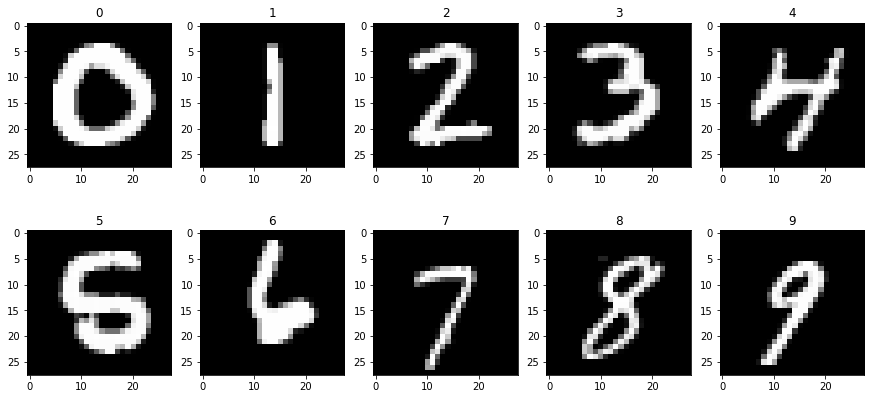

In [5]:
plt.figure(figsize=(15,7))
for i, c in enumerate(np.arange(0,10), start=1):
    t = train[train['label']==c].values[1]
    t = t[1:]
    plt.subplot(2,5,i)
    plt.title(c)
    plt.imshow(t.reshape(28,28), cmap='gray')

In [6]:
X = train.iloc[:, 1:].values
y = train.iloc[:, 0].values

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
X_test = test.values
X_test.shape

(28000, 784)

In [9]:
X_test_scaled = scaler.fit_transform(X_test)
X_test_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [10]:
X = X.reshape((42000, 28, 28, 1))

In [11]:
datagen = ImageDataGenerator(rotation_range=10,  zoom_range = 0.1,  width_shift_range=0.1,  height_shift_range=0.1)

In [12]:
model = Sequential()
model.add(Conv2D(32, kernel_size = 3, activation = 'relu', padding = 'same', input_shape = [28, 28, 1]))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size = 3, activation = 'relu', padding = 'same'))
model.add(MaxPool2D())
model.add(Conv2D(32, kernel_size = 3, activation = 'relu', padding = 'same'))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size = 3, activation = 'relu', padding = 'same'))
model.add(MaxPool2D())
model.add(Flatten())
model.add(Dropout(0.25))
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])

2023-01-18 13:02:51.675240: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-18 13:02:51.777444: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-18 13:02:51.778251: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-18 13:02:51.779612: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.08)
model.summary()
history= model.fit_generator(datagen.flow(X, y, batch_size = 64), 
                                             epochs = 20, validation_data = (X_valid, y_valid))

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        320       
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 32)        128       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 14, 14, 32)        18464     
_________________________________________________________________
batch_normalization_1 (Batch (None, 14, 14, 32)        128       
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 14, 14, 64)        1

/opt/conda/lib/python3.7/site-packages/keras/engine/training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '
2023-01-18 13:02:55.242172: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/20


2023-01-18 13:02:57.432313: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


657/657 [==============================] - 22s 21ms/step - loss: 0.4102 - accuracy: 0.8747 - val_loss: 0.0685 - val_accuracy: 0.9786
Epoch 2/20
657/657 [==============================] - 13s 20ms/step - loss: 0.1394 - accuracy: 0.9594 - val_loss: 0.0891 - val_accuracy: 0.9723
Epoch 3/20
657/657 [==============================] - 13s 20ms/step - loss: 0.1040 - accuracy: 0.9698 - val_loss: 0.0598 - val_accuracy: 0.9860
Epoch 4/20
657/657 [==============================] - 13s 19ms/step - loss: 0.0888 - accuracy: 0.9734 - val_loss: 0.0333 - val_accuracy: 0.9893
Epoch 5/20
657/657 [==============================] - 13s 20ms/step - loss: 0.0760 - accuracy: 0.9780 - val_loss: 0.0340 - val_accuracy: 0.9881
Epoch 6/20
657/657 [==============================] - 13s 20ms/step - loss: 0.0712 - accuracy: 0.9794 - val_loss: 0.0255 - val_accuracy: 0.9937
Epoch 7/20
657/657 [==============================] - 13s 19ms/step - loss: 0.0679 - accuracy: 0.9796 - val_loss: 0.0326 - val_accuracy: 0.9884
Epo

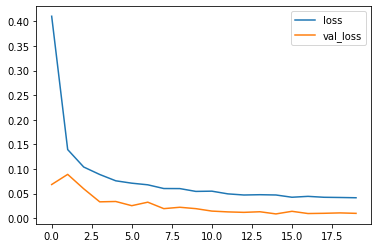

In [14]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'],loc='upper right')
plt.show()

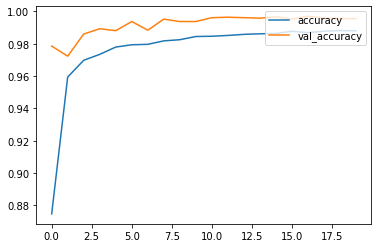

In [15]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy','val_accuracy'],loc='upper right')
plt.show()

In [16]:
ensemble_cnn_pred = np.zeros((X_test.shape[0], 10))
ensemble_cnn_pred.shape

(28000, 10)

In [17]:
X_test_scaled = X_test_scaled.reshape((28000, 28, 28, 1))
X_test_scaled.shape

(28000, 28, 28, 1)

In [18]:
ensemble_cnn_pred = ensemble_cnn_pred + model.predict(X_test_scaled)
    
np.sum(ensemble_cnn_pred[0])

1.0000000000002158

In [19]:
ensemble_cnn_pred = np.argmax(ensemble_cnn_pred, axis = 1)
ensemble_cnn_pred[0]

2

In [20]:
ensemble_cnn_pred.shape

(28000,)

In [21]:
pred_df_ensemble_cnn = pd.DataFrame(columns = ['ImageId', 'Label'])
pred_df_ensemble_cnn['ImageId'] = np.arange(1, 28001)
pred_df_ensemble_cnn['Label'] = ensemble_cnn_pred
pred_df_ensemble_cnn

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [22]:
pred_df_ensemble_cnn.to_csv('submission.csv', index = False)